In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import networkx as nx
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from arch import *
from utils import get_data_dict, seed_everything, node_homophily_per_node
from model import train_model

import torch_geometric.utils as tu

import logging

logging.basicConfig(format='%(asctime)s %(message)s', level=logging.INFO)

# Data loading

In [2]:
seed = 0
seed_everything(seed)

In [3]:
data_np = np.load('node_embeddings/embedding_graphs.npz', allow_pickle=True)

In [4]:
all_graphs = {}
for filename in data_np.files:
    dataset = filename.split('_')[0]
    file = filename.split('_')[1]
    if dataset not in all_graphs:
        all_graphs[dataset] = {}
    if file not in all_graphs[dataset]:
        all_graphs[dataset][file] = data_np[filename]

In [5]:
datasets = ['Texas', 'Wisconsin', 'Cornell', 'Actor', 'Chameleon', 'Squirrel', 'Cora', 'CiteSeer', 'USA', 'Europe', 'Brazil']
# datasets = ['Texas', 'Actor', 'Cora']

node_name = 'web'

In [6]:
graphs = list(all_graphs[datasets[0]].keys())
del graphs[graphs.index('EPS-GraphWave')]
n_graphs = len(graphs)
graphs

['Original',
 'EPS-Feat',
 'KNN-Feat',
 'EPS-RoleFeat',
 'KNN-RoleFeat',
 'EPS-GlobalFeat',
 'KNN-GlobalFeat',
 'EPS-DeepWalk',
 'KNN-DeepWalk',
 'EPS-Node2Vec',
 'KNN-Node2Vec',
 'EPS-Struc2Vec',
 'KNN-Struc2Vec',
 'KNN-GraphWave']

In [7]:
data_dict = get_data_dict(datasets, all_graphs, node_name, 10, 0.8, 0.1)

2025-06-09 16:58:52,464 Reading and processing data for Texas
2025-06-09 16:58:52,474 Reading and processing data for Wisconsin
2025-06-09 16:58:52,479 Reading and processing data for Cornell
2025-06-09 16:58:52,483 Reading and processing data for Actor
2025-06-09 16:58:52,580 Reading and processing data for Chameleon
2025-06-09 16:58:52,607 Reading and processing data for Squirrel
2025-06-09 16:58:52,676 Reading and processing data for Cora
2025-06-09 16:58:52,930 Reading and processing data for CiteSeer
2025-06-09 16:58:53,274 Reading and processing data for USA
2025-06-09 16:58:53,350 Reading and processing data for Europe
2025-06-09 16:58:53,358 Reading and processing data for Brazil


In [8]:
A_stars = {}

for d, dataset_name in enumerate(datasets):
    data_pyg = data_dict[dataset_name]

    edge_idx = data_pyg[node_name, 'Original', node_name].edge_index
    y = data_pyg[node_name]['y']
    new_edge_idx = []
    for edge in data_pyg[node_name, 'Original', node_name].edge_index.t():
        if y[edge[0]] == y[edge[1]]:
            new_edge_idx.append(edge)
    A_stars[dataset_name] = torch.stack(new_edge_idx).t()

In [9]:
gs_eval = ['Original', 'KNN-Feat', 'KNN-RoleFeat', 'KNN-GlobalFeat', 'EPS-RoleFeat', 'EPS-GlobalFeat']
gs_eval_name = ['$\\mathcal{G}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm feat}}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm role}}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm global}}$', '$\\mathcal{G}_{\\epsilon,{\\rm role}}$', '$\\mathcal{G}_{\\epsilon,{\\rm global}}$']
gs_eval = ['Original', 'KNN-Feat', 'KNN-RoleFeat', 'KNN-GlobalFeat']
gs_eval_name = ['$\\mathcal{G}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm feat}}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm role}}$', '$\\mathcal{G}^{\\rm nn}_{k,{\\rm glob}}$']

# Homophily metrics

In [10]:
edge_homophily = np.zeros((len(datasets), len(gs_eval)))
node_homophily = np.zeros((len(datasets), len(gs_eval)))
homophilies_per_node = {}
edge_ins_homophily = np.zeros((len(datasets), len(gs_eval)))
total_variation = np.zeros((len(datasets), len(gs_eval)))

for d, dataset_name in enumerate(datasets):
    data_pyg = data_dict[dataset_name]
    y = data_pyg[node_name]['y']
    num_classes = len(torch.unique(y))
    Y = torch.nn.functional.one_hot(y, num_classes=num_classes).float()

    homophilies_per_node[dataset_name] = {}

    for g, graph_name in enumerate(gs_eval):
        edge_idx, _ = tu.remove_self_loops(data_pyg[node_name, graph_name, node_name].edge_index.clone().cpu())
        edge_idx = tu.to_undirected(edge_idx)
        A = torch.zeros((data_pyg[node_name].N, data_pyg[node_name].N))
        A[edge_idx[0,:], edge_idx[1,:]] = 1.
        
        edge_homophily[d, g] = tu.homophily(edge_idx, y)
        node_homophily[d, g] = tu.homophily(edge_idx, y, method="node")
        edge_ins_homophily[d, g] = tu.homophily(edge_idx, y, method="edge_insensitive")
        homophilies_per_node[dataset_name][graph_name] = node_homophily_per_node(edge_idx, y)

        # norm_A = A / torch.max(torch.abs(torch.linalg.eigvals(A)))
        A += torch.eye(data_pyg[node_name].N)  # Add self-loops
        deg = A.sum(1)
        D_inv = torch.diag(torch.pow(deg, -0.5))
        
        norm_A = D_inv @ A @ D_inv
        
        AY = torch.matmul(norm_A, Y)
        total_variation[d, g] = torch.norm(Y - AY, p=1).item() / (num_classes * data_pyg[node_name].N)

# Combine edge homophily and total variation into a single DataFrame
columns = [f'{metric}_{graph}' for metric in ['TotalVariation', 'EdgeHomophily'] for graph in gs_eval]
data = np.hstack((total_variation, edge_homophily))
df_combined = pd.DataFrame(data, index=datasets, columns=columns)

df_combined

,TotalVariation_Original,TotalVariation_KNN-Feat,TotalVariation_KNN-RoleFeat,TotalVariation_KNN-GlobalFeat,EdgeHomophily_Original,EdgeHomophily_KNN-Feat,EdgeHomophily_KNN-RoleFeat,EdgeHomophily_KNN-GlobalFeat
Texas,0.213064,0.149039,0.149451,0.154226,0.060932,0.559702,0.614078,0.579634
Wisconsin,0.213250,0.138496,0.183843,0.186503,0.177778,0.565585,0.455197,0.452652
Cornell,0.204255,0.145646,0.171219,0.178338,0.122744,0.555556,0.481043,0.457364
Actor,0.218080,0.221915,0.241788,0.245245,0.216737,0.222012,0.208474,0.212774
Chameleon,0.241650,0.204602,0.150493,0.152186,0.229926,0.206238,0.652803,0.649752
Squirrel,0.255235,0.207935,0.156863,0.156258,0.222134,0.192474,0.540505,0.544080
Cora,0.053558,0.115485,0.146194,0.144210,0.809966,0.398078,0.342685,0.348129
CiteSeer,0.072044,0.123454,0.167218,0.164370,0.735501,0.125882,0.295088,0.309485
USA,0.201753,0.204198,0.199195,0.184562,0.697845,0.249158,0.502212,0.543590
Europe,0.293033,0.215033,0.219332,0.208525,0.404639,0.246012,0.448750,0.474214


In [11]:
print(df_combined.style.format(precision=4).to_latex())

\begin{tabular}{lrrrrrrrr}
 & TotalVariation_Original & TotalVariation_KNN-Feat & TotalVariation_KNN-RoleFeat & TotalVariation_KNN-GlobalFeat & EdgeHomophily_Original & EdgeHomophily_KNN-Feat & EdgeHomophily_KNN-RoleFeat & EdgeHomophily_KNN-GlobalFeat \\
Texas & 0.2131 & 0.1490 & 0.1495 & 0.1542 & 0.0609 & 0.5597 & 0.6141 & 0.5796 \\
Wisconsin & 0.2133 & 0.1385 & 0.1838 & 0.1865 & 0.1778 & 0.5656 & 0.4552 & 0.4527 \\
Cornell & 0.2043 & 0.1456 & 0.1712 & 0.1783 & 0.1227 & 0.5556 & 0.4810 & 0.4574 \\
Actor & 0.2181 & 0.2219 & 0.2418 & 0.2452 & 0.2167 & 0.2220 & 0.2085 & 0.2128 \\
Chameleon & 0.2417 & 0.2046 & 0.1505 & 0.1522 & 0.2299 & 0.2062 & 0.6528 & 0.6498 \\
Squirrel & 0.2552 & 0.2079 & 0.1569 & 0.1563 & 0.2221 & 0.1925 & 0.5405 & 0.5441 \\
Cora & 0.0536 & 0.1155 & 0.1462 & 0.1442 & 0.8100 & 0.3981 & 0.3427 & 0.3481 \\
CiteSeer & 0.0720 & 0.1235 & 0.1672 & 0.1644 & 0.7355 & 0.1259 & 0.2951 & 0.3095 \\
USA & 0.2018 & 0.2042 & 0.1992 & 0.1846 & 0.6978 & 0.2492 & 0.5022 & 0.5436 \\
Eur

## Homophily histograms

2025-06-09 16:58:59,931 Substituting symbol G from STIXNonUnicode
2025-06-09 16:58:59,934 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:00,438 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:00,441 Substituting symbol G from STIXNonUnicode


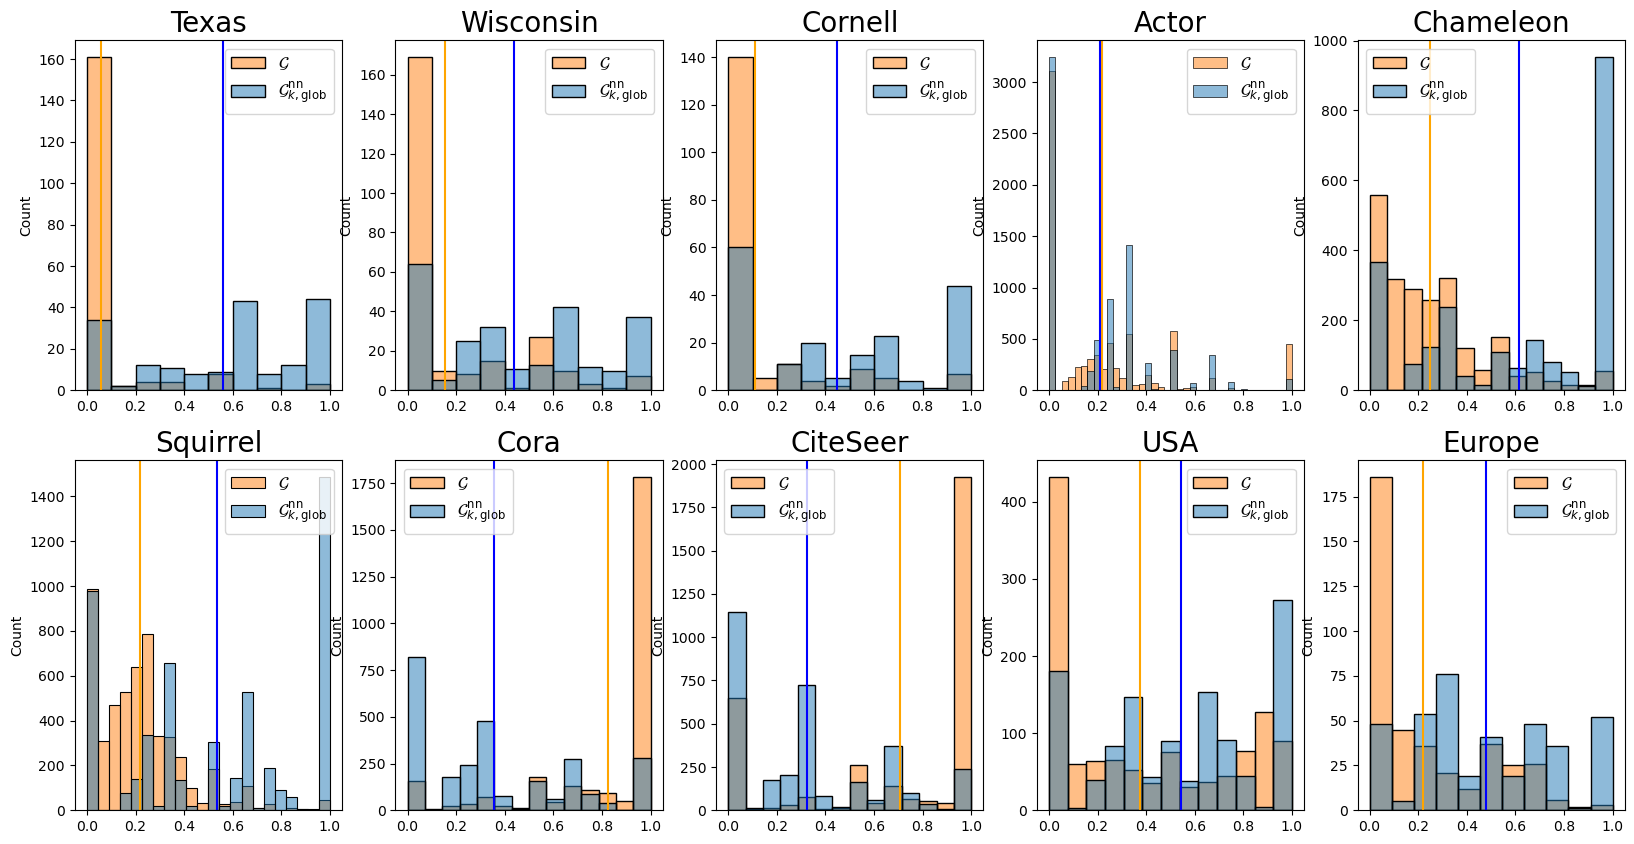

In [12]:
f, ax = plt.subplots(2,len(datasets)//2,figsize=(20,10))

for d, ax in enumerate(ax.ravel()):
    node_homophilies_orig = homophilies_per_node[datasets[d]]['Original'].numpy()
    node_homophilies_knn = homophilies_per_node[datasets[d]]['KNN-GlobalFeat'].numpy()
    
    sns.histplot([node_homophilies_knn,node_homophilies_orig], ax=ax)
    ax.legend([gs_eval_name[gs_eval.index(elem)] for elem in ['Original', 'KNN-GlobalFeat']], fontsize=12)
    ax.axvline(node_homophilies_orig.mean(), color='orange')
    ax.axvline(node_homophilies_knn.mean(), color='b')
    
    ax.set_title(datasets[d], fontsize=20)

2025-06-09 16:59:00,897 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:00,899 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,067 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,070 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,187 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,189 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,432 Substituting symbol G from STIXNonUnicode
2025-06-09 16:59:01,435 Substituting symbol G from STIXNonUnicode


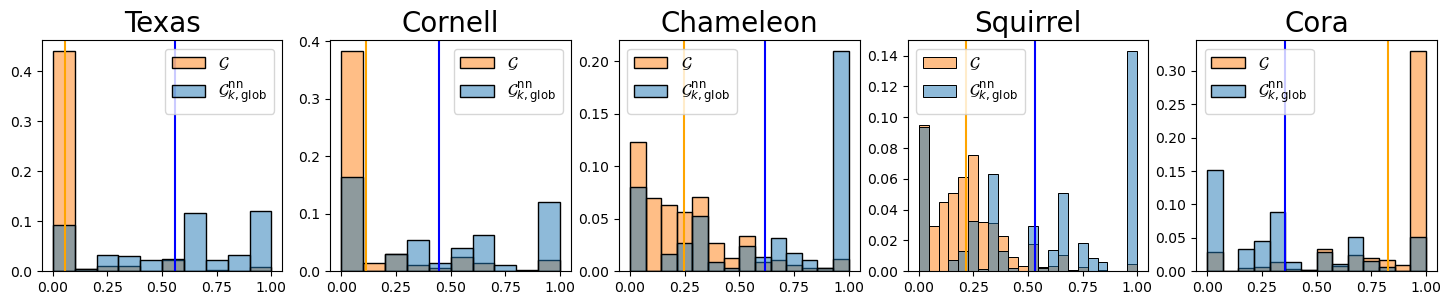

In [13]:
datasets_plot = ['Texas', 'Cornell', 'Chameleon', 'Squirrel', 'Cora']
f, ax = plt.subplots(1,len(datasets_plot),figsize=(18,3))

for d, ax in enumerate(ax.ravel()):
    node_homophilies_orig = homophilies_per_node[datasets_plot[d]]['Original'].numpy()
    node_homophilies_knn = homophilies_per_node[datasets_plot[d]]['KNN-GlobalFeat'].numpy()
    
    sns.histplot([node_homophilies_knn,node_homophilies_orig], stat="proportion", ax=ax) # For some reason the order is reversed
    ax.legend([gs_eval_name[gs_eval.index(elem)] for elem in ['Original', 'KNN-GlobalFeat']], fontsize=12)
    ax.axvline(node_homophilies_orig.mean(), color='orange')
    ax.axvline(node_homophilies_knn.mean(), color='b')
    ax.set_ylabel('')
    ax.set_title(datasets_plot[d], fontsize=20)

f.savefig('results/node_homophily_per_node.pdf', bbox_inches='tight')

# $q$ values

In [13]:
ratios_diff_labels = np.zeros((len(datasets), len(gs_eval)))

for d, dataset_name in enumerate(datasets):
    data_pyg = data_dict[dataset_name]
    y = data_pyg[node_name]['y']

    diff_label_pairs = []
    for i in range(data_pyg[node_name].N):
        for j in range(i+1, data_pyg[node_name].N):
            if y[i] != y[j]:
                diff_label_pairs.append((i, j))
    diff_label_pairs = torch.tensor(diff_label_pairs).t()
    num_diff_label_pairs = diff_label_pairs.size(1)
    
    for g, graph_name in enumerate(gs_eval):
        edge_idx, _ = tu.remove_self_loops(data_pyg[node_name, graph_name, node_name].edge_index.clone().cpu())
        A = torch.zeros((data_pyg[node_name].N, data_pyg[node_name].N))
        A[edge_idx[0,:], edge_idx[1,:]] = 1.
        
        num_diff_label_edges = torch.sum(A[diff_label_pairs[0], diff_label_pairs[1]]).item()
        ratios_diff_labels[d, g] = num_diff_label_edges / num_diff_label_pairs

df_qs = pd.DataFrame(ratios_diff_labels, index=datasets, columns=gs_eval_name)
df_qs

,$\mathcal{G}$,"$\mathcal{G}_{k,{\rm feat}}$","$\mathcal{G}_{k,{\rm role}}$","$\mathcal{G}_{k,{\rm global}}$"
Texas,0.014971,0.012873,0.007342,0.010775
Wisconsin,0.009481,0.006383,0.007791,0.009387
Cornell,0.012146,0.008544,0.008544,0.010136
Actor,0.000517,0.000192,0.000346,0.000376
Chameleon,0.008608,0.000513,0.000557,0.000549
Squirrel,0.011317,0.000300,0.000303,0.000298
Cora,0.000333,0.000624,0.000804,0.000809
CiteSeer,0.000265,0.001389,0.000475,0.000509
USA,0.003222,0.000009,0.001373,0.001490
Europe,0.000000,0.000050,0.005595,0.005277


In [14]:
print(df_qs.style.format(precision=4).to_latex())

\begin{tabular}{lrrrr}
 & $\mathcal{G}$ & $\mathcal{G}_{k,{\rm feat}}$ & $\mathcal{G}_{k,{\rm role}}$ & $\mathcal{G}_{k,{\rm global}}$ \\
Texas & 0.0150 & 0.0129 & 0.0073 & 0.0108 \\
Wisconsin & 0.0095 & 0.0064 & 0.0078 & 0.0094 \\
Cornell & 0.0121 & 0.0085 & 0.0085 & 0.0101 \\
Actor & 0.0005 & 0.0002 & 0.0003 & 0.0004 \\
Chameleon & 0.0086 & 0.0005 & 0.0006 & 0.0005 \\
Squirrel & 0.0113 & 0.0003 & 0.0003 & 0.0003 \\
Cora & 0.0003 & 0.0006 & 0.0008 & 0.0008 \\
CiteSeer & 0.0003 & 0.0014 & 0.0005 & 0.0005 \\
USA & 0.0032 & 0.0000 & 0.0014 & 0.0015 \\
Europe & 0.0000 & 0.0001 & 0.0056 & 0.0053 \\
Brazil & 0.0527 & 0.0000 & 0.0120 & 0.0117 \\
\end{tabular}



# $\| \Delta \|_F$

In [14]:
norms_diff_labels = {}

errs_non_same_edge = np.zeros((len(datasets), len(gs_eval)))

for d, dataset_name in enumerate(datasets):
    data_pyg = data_dict[dataset_name]
    y = data_pyg[node_name]['y']
    N = data_pyg[node_name].N

    diff_label_pairs = []
    for i in range(data_pyg[node_name].N):
        for j in range(data_pyg[node_name].N):
            if y[i] != y[j]:
                diff_label_pairs.append((i, j))
    diff_label_pairs = torch.tensor(diff_label_pairs).t()
    
    norms_diff_labels[dataset_name] = {}
    
    for g, graph_name in enumerate(gs_eval):
        edge_idx, _ = tu.remove_self_loops(data_pyg[node_name, graph_name, node_name].edge_index.clone().cpu())
        A = torch.zeros((N, N))
        A[edge_idx[0,:], edge_idx[1,:]] = 1.
        
        errs_non_same_edge[d, g] = torch.norm(A[diff_label_pairs[0], diff_label_pairs[1]]).item() / torch.norm(A) # N

df_delta = pd.DataFrame(errs_non_same_edge, index=datasets, columns=gs_eval_name)
df_delta

,$\mathcal{G}$,"$\mathcal{G}_{k,{\rm feat}}$","$\mathcal{G}_{k,{\rm role}}$","$\mathcal{G}_{k,{\rm global}}$"
Texas,0.968768,0.662556,0.618477,0.647258
Wisconsin,0.910856,0.644725,0.743274,0.744167
Cornell,0.936998,0.663929,0.720504,0.737988
Actor,0.885249,0.880017,0.890619,0.888030
Chameleon,0.875245,0.886222,0.596187,0.598881
Squirrel,0.881225,0.897917,0.659190,0.661180
Cora,0.435929,0.768422,0.800972,0.796580
CiteSeer,0.514295,0.921637,0.826922,0.816374
USA,0.549686,0.866591,0.701140,0.667996
Europe,0.771597,0.867592,0.741986,0.720855


In [15]:
print(df_delta.style.format(precision=4).to_latex())

\begin{tabular}{lrrrr}
 & $\mathcal{G}$ & $\mathcal{G}_{k,{\rm feat}}$ & $\mathcal{G}_{k,{\rm role}}$ & $\mathcal{G}_{k,{\rm global}}$ \\
Texas & 0.9688 & 0.6626 & 0.6185 & 0.6473 \\
Wisconsin & 0.9109 & 0.6447 & 0.7433 & 0.7442 \\
Cornell & 0.9370 & 0.6639 & 0.7205 & 0.7380 \\
Actor & 0.8852 & 0.8800 & 0.8906 & 0.8880 \\
Chameleon & 0.8752 & 0.8862 & 0.5962 & 0.5989 \\
Squirrel & 0.8812 & 0.8979 & 0.6592 & 0.6612 \\
Cora & 0.4359 & 0.7684 & 0.8010 & 0.7966 \\
CiteSeer & 0.5143 & 0.9216 & 0.8269 & 0.8164 \\
USA & 0.5497 & 0.8666 & 0.7011 & 0.6680 \\
Europe & 0.7716 & 0.8676 & 0.7420 & 0.7209 \\
Brazil & 0.7545 & 0.8693 & 0.6692 & 0.6341 \\
\end{tabular}



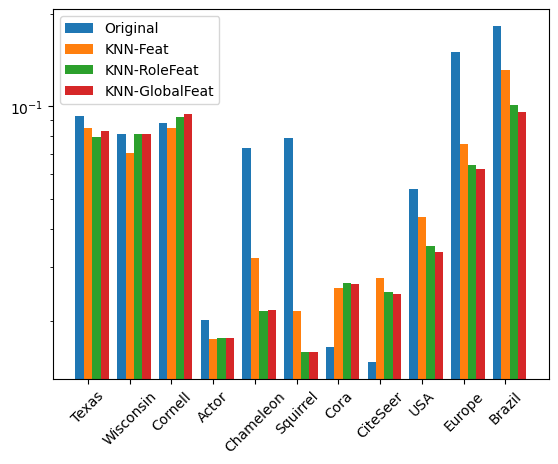

In [17]:
for g, graph_name in enumerate(gs_eval):

    plt.bar(np.arange(len(datasets))+((g-1)*0.2), errs_non_same_edge[:,g], width=0.2, label=graph_name)

    plt.yscale('log')

    plt.xticks(np.arange(len(datasets)), datasets, rotation=45)

plt.legend()

# Synthetic graph

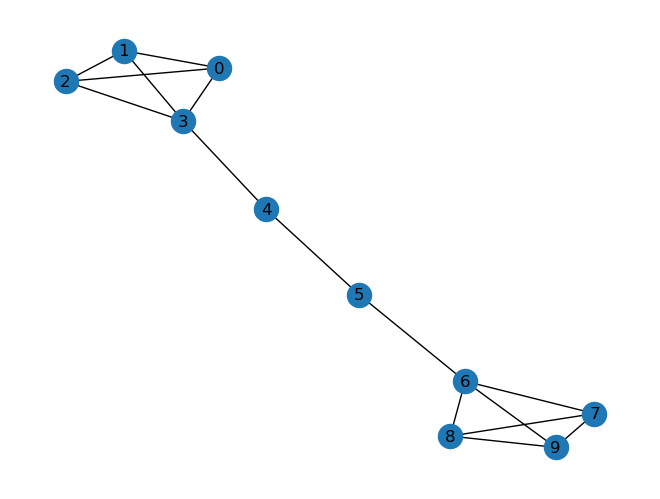

In [41]:
size_bb = 4
size_path = 2
bbgraph = nx.barbell_graph(size_bb, size_path)
nx.draw(bbgraph, with_labels=True)

In [42]:
import sys
sys.path.append('node_embeddings')
from embeddings import RoleFeatEmbeddings, GlobalFeatEmbeddings
from torch_geometric.utils import from_networkx
tu_bbgraph = from_networkx(bbgraph)
# Add the degree as the node features
tu_bbgraph.x = torch.tensor([[d] for d in dict(bbgraph.degree()).values()], dtype=torch.float)
role_based = RoleFeatEmbeddings(tu_bbgraph, nneigh=2)
global_based = GlobalFeatEmbeddings(tu_bbgraph, nneigh=2)

/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:229: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:229: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


In [43]:
role_based_g = nx.from_numpy_array(role_based.knn_graph)
global_based_g = nx.from_numpy_array(global_based.knn_graph)

In [44]:
labels = torch.tensor([0]*(size_bb-1) + [1] + [2]*size_path + [1] + [0]*(size_bb-1))

homophily_bb = tu.homophily(tu_bbgraph.edge_index, labels)
homophily_role = tu.homophily(from_networkx(role_based_g).edge_index, labels)
homophily_global = tu.homophily(from_networkx(global_based_g).edge_index, labels)
print(f"Homophily for Barbell Graph: {homophily_bb:.4f} - RoleFeat: {homophily_role:.4f} - GlobalFeat: {homophily_global:.4f}")

Homophily for Barbell Graph: 0.4667 - RoleFeat: 0.7333 - GlobalFeat: 0.7333


In [45]:
def draw_pretty_graph(graph, node_color=None, edge_color=None, layout=None, ax=None, title=None):
    plt.figure(figsize=(8, 6))
    nx.draw(graph, layout, with_labels=True, node_color=node_color, edge_color=edge_color, node_size=300, linewidths=2, width=2, edgecolors='k', ax=ax)
    if title:
        ax.set_title(title, fontsize=14)

2025-06-05 19:29:15,928 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:15,945 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:15,976 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:15,989 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:16,025 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:16,037 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:16,081 Substituting symbol G from STIXNonUnicode
2025-06-05 19:29:16,093 Substituting symbol G from STIXNonUnicode


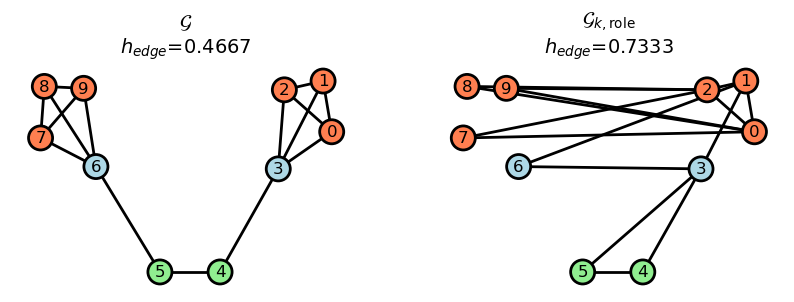

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [46]:
seed = 0
colors = ['coral']*(size_bb-1) + ['lightblue'] + ['lightgreen']*size_path + ['lightblue'] + ['coral']*(size_bb-1)

layout = nx.spring_layout(bbgraph, seed=seed)
for i in range(size_bb):
    layout[i] = np.array((layout[i][0], -layout[i][1]))
layout[size_bb] = np.array((layout[size_bb][0], layout[size_bb+1][1]))

f, ax = plt.subplots(1, 2, figsize=(10, 3))

draw_pretty_graph(bbgraph, node_color=colors, layout=layout, ax=ax[0], title=f'$\\mathcal{{G}}$\n$h_{{edge}}$={homophily_bb:.4f}')
draw_pretty_graph(role_based_g, node_color=colors, layout=layout, ax=ax[1], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{role}}}}}}$\n$h_{{edge}}$={homophily_role:.4f}')
# draw_pretty_graph(global_based_g, node_color=colors, layout=layout, ax=ax[2], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{glob}}}}}}$\n$h_{{edge}}$={homophily_global:.4f}')

f.savefig('results/barbell_graph.pdf', bbox_inches='tight')

2025-05-30 14:28:20,566 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,580 Substituting symbol G from STIXNonUnicode


2025-05-30 14:28:20,598 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,634 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,647 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,662 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,696 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,707 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,722 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,777 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,788 Substituting symbol G from STIXNonUnicode
2025-05-30 14:28:20,802 Substituting symbol G from STIXNonUnicode


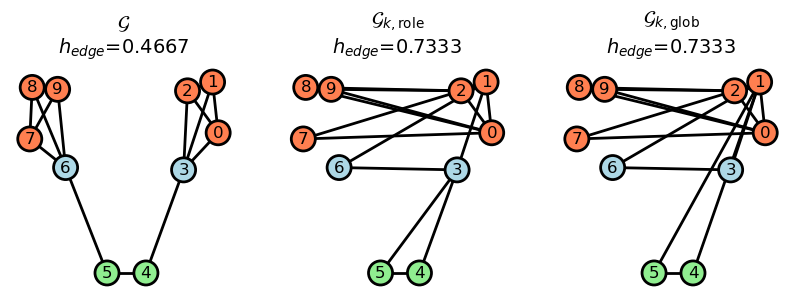

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [17]:
seed = 0
colors = ['coral']*(size_bb-1) + ['lightblue'] + ['lightgreen']*size_path + ['lightblue'] + ['coral']*(size_bb-1)

layout = nx.spring_layout(bbgraph, seed=seed)
for i in range(size_bb):
    layout[i] = np.array((layout[i][0], -layout[i][1]))
layout[size_bb] = np.array((layout[size_bb][0], layout[size_bb+1][1]))

f, ax = plt.subplots(1, 3, figsize=(10, 3))

draw_pretty_graph(bbgraph, node_color=colors, layout=layout, ax=ax[0], title=f'$\\mathcal{{G}}$\n$h_{{edge}}$={homophily_bb:.4f}')
draw_pretty_graph(role_based_g, node_color=colors, layout=layout, ax=ax[1], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{role}}}}}}$\n$h_{{edge}}$={homophily_role:.4f}')
draw_pretty_graph(global_based_g, node_color=colors, layout=layout, ax=ax[2], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{glob}}}}}}$\n$h_{{edge}}$={homophily_global:.4f}')

f.savefig('results/barbell_graph.pdf', bbox_inches='tight')

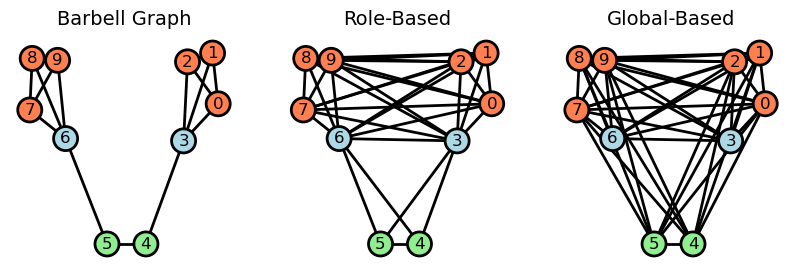

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [18]:
role_based_g = nx.from_numpy_array(role_based.eps_graph)
global_based_g = nx.from_numpy_array(global_based.eps_graph)

seed = 0
colors = ['coral']*(size_bb-1) + ['lightblue'] + ['lightgreen']*size_path + ['lightblue'] + ['coral']*(size_bb-1)
layout = nx.spring_layout(bbgraph, seed=seed)
for i in range(4):
    layout[i] = np.array((layout[i][0], -layout[i][1]))
layout[4] = np.array((layout[4][0], layout[5][1]))

f, ax = plt.subplots(1, 3, figsize=(10, 3))

draw_pretty_graph(bbgraph, node_color=colors, layout=layout, ax=ax[0], title='Barbell Graph')
draw_pretty_graph(role_based_g, node_color=colors, layout=layout, ax=ax[1], title='Role-Based')
draw_pretty_graph(global_based_g, node_color=colors, layout=layout, ax=ax[2], title='Global-Based')

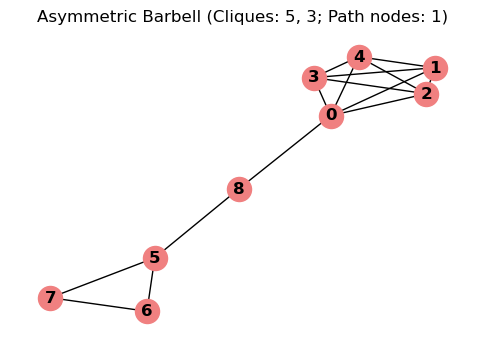

In [27]:
# --- 1. Barbell with Asymmetric Cliques ---
m1_clique1 = 5  # Larger clique
m1_clique2 = 3  # Smaller clique
m2_path_asym = 1 # Path nodes between them

# We need to construct this manually as nx.barbell_graph assumes symmetric cliques
g_asym = nx.Graph()
clique1_nodes = list(range(m1_clique1))
clique2_nodes = list(range(m1_clique1, m1_clique1 + m1_clique2))
path_nodes = list(range(m1_clique1 + m1_clique2, m1_clique1 + m1_clique2 + m2_path_asym))

# Add cliques
g_asym.add_edges_from(nx.complete_graph(clique1_nodes).edges())
g_asym.add_edges_from(nx.complete_graph(clique2_nodes).edges())

# Add path nodes
if m2_path_asym > 0:
    for i in range(m2_path_asym - 1):
        g_asym.add_edge(path_nodes[i], path_nodes[i+1])

    # Connect path to cliques
    g_asym.add_edge(clique1_nodes[0], path_nodes[0]) # Connect first clique to start of path
    g_asym.add_edge(clique2_nodes[0], path_nodes[-1]) # Connect second clique to end of path
elif m1_clique1 > 0 and m1_clique2 > 0 : # m2_path_asym == 0, direct connection
    g_asym.add_edge(clique1_nodes[0], clique2_nodes[0])


plt.figure(figsize=(6, 4))
plt.title(f"Asymmetric Barbell (Cliques: {m1_clique1}, {m1_clique2}; Path nodes: {m2_path_asym})")
pos_asym = nx.spring_layout(g_asym, seed=42) # Use a layout for better visualization
nx.draw(g_asym, pos_asym, with_labels=True, node_color='lightcoral', font_weight='bold')
plt.show()
bbgraph_asymmetric = g_asym


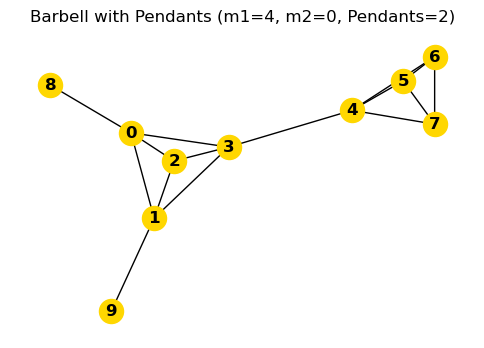

In [35]:
# --- 3. Barbell with Pendants on one Clique ---
m1_pendants = 4
m2_pendants_path = 0 # Direct connection between cliques for simplicity here
num_pendants = 2

g_pendants = nx.barbell_graph(m1_pendants, m2_pendants_path)
nodes_clique1 = list(range(m1_pendants)) # Nodes 0 to m1_pendants-1 are in the first clique

next_node_idx = max(g_pendants.nodes()) + 1
for i in range(num_pendants):
    if i < len(nodes_clique1): # Ensure we don't try to attach to non-existent clique nodes
        g_pendants.add_edge(nodes_clique1[i], next_node_idx)
        next_node_idx += 1

plt.figure(figsize=(6, 4))
plt.title(f"Barbell with Pendants (m1={m1_pendants}, m2={m2_pendants_path}, Pendants={num_pendants})")
pos_pendants = nx.spring_layout(g_pendants, seed=42)
nx.draw(g_pendants, pos_pendants, with_labels=True, node_color='gold', font_weight='bold')
plt.show()
bbgraph_with_pendants = g_pendants

# --- Example of a Barbell with a Central Hub (more complex) ---
# Two cliques, a path between them, and one hub node connected to one node from each clique path end.
m1_clique_hub = 3
m2_path_hub = 1 # One node in the path

g_hub = nx.Graph()
cliqueA_nodes = [0, 1, 2]
cliqueB_nodes = [3, 4, 5]
path_node_hub = 6 # The node in the path
hub_node = 7    # The central hub

# Add cliques
g_hub.add_edges_from(nx.complete_graph(cliqueA_nodes).edges())
g_hub.add_edges_from(nx.complete_graph(cliqueB_nodes).edges())

# Connect cliques to path node
g_hub.add_edge(cliqueA_nodes[0], path_node_hub)
g_hub.add_edge(cliqueB_nodes[0], path_node_hub)

# Add hub node and connect it
g_hub.add_node(hub_node)
g_hub.add_edge(cliqueA_nodes[1], hub_node) # Connect hub to a node in clique A
g_hub.add_edge(cliqueB_nodes[1], hub_node) # Connect hub to a node in clique B


In [36]:
tu_g_pendants = from_networkx(g_pendants)
# Add the degree as the node features
tu_g_pendants.x = torch.tensor([[d] for d in dict(g_pendants.degree()).values()], dtype=torch.float)
role_based = RoleFeatEmbeddings(tu_g_pendants, nneigh=2)
global_based = GlobalFeatEmbeddings(tu_g_pendants, nneigh=2)

/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:229: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:229: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


In [37]:
role_based_g = nx.from_numpy_array(role_based.knn_graph)
global_based_g = nx.from_numpy_array(global_based.knn_graph)

In [38]:
#labels = torch.tensor([0, 1, 1, 1, 1, 0, 2, 2, 3])
labels = torch.tensor([0, 0, 0, 1, 1, 0, 0, 0, 2, 2])

homophily_bb = tu.homophily(tu_g_pendants.edge_index, labels)
homophily_role = tu.homophily(from_networkx(role_based_g).edge_index, labels)
homophily_global = tu.homophily(from_networkx(global_based_g).edge_index, labels)
print(f"Homophily for Barbell Graph: {homophily_bb:.4f} - RoleFeat: {homophily_role:.4f} - GlobalFeat: {homophily_global:.4f}")

Homophily for Barbell Graph: 0.4667 - RoleFeat: 0.5385 - GlobalFeat: 0.5833


2025-06-05 19:27:27,099 Substituting symbol G from STIXNonUnicode
2025-06-05 19:27:27,114 Substituting symbol G from STIXNonUnicode
2025-06-05 19:27:27,133 Substituting symbol G from STIXNonUnicode
2025-06-05 19:27:27,187 Substituting symbol G from STIXNonUnicode
2025-06-05 19:27:27,199 Substituting symbol G from STIXNonUnicode
2025-06-05 19:27:27,212 Substituting symbol G from STIXNonUnicode


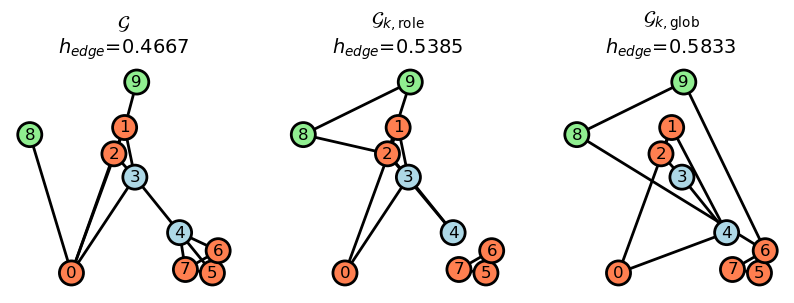

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [40]:
seed = 0
# Give me colors with the same sequence as labels
colors = ['coral', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'coral', 'lightgreen', 'lightgreen', 'yellow']
colors = ['coral', 'coral', 'coral', 'lightblue', 'lightblue', 'coral', 'coral', 'coral', 'lightgreen', 'lightgreen']

layout = nx.spring_layout(g_pendants, seed=seed)
layout[0] = (-layout[5][0], layout[5][1])  # Adjust the layout for the asymmetric barbell graph

f, ax = plt.subplots(1, 3, figsize=(10, 3))

draw_pretty_graph(g_pendants, node_color=colors, layout=layout, ax=ax[0], title=f'$\\mathcal{{G}}$\n$h_{{edge}}$={homophily_bb:.4f}')
draw_pretty_graph(role_based_g, node_color=colors, layout=layout, ax=ax[1], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{role}}}}}}$\n$h_{{edge}}$={homophily_role:.4f}')
draw_pretty_graph(global_based_g, node_color=colors, layout=layout, ax=ax[2], title=f'$\\mathcal{{G}}_{{k,{{\\mathrm{{glob}}}}}}$\n$h_{{edge}}$={homophily_global:.4f}')
